In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Define your base project path
BASE_PATH = '/content/drive/MyDrive/FER2013_Project'
TRAIN_PATH = os.path.join(BASE_PATH, 'train')
TEST_PATH  = os.path.join(BASE_PATH, 'test')

# Check folders exist
print("Base folder exists:", os.path.exists(BASE_PATH))
print("Train folder exists:", os.path.exists(TRAIN_PATH))
print("Test folder exists:", os.path.exists(TEST_PATH))

# Show the 7 emotion classes
classes = sorted(os.listdir(TRAIN_PATH))
print("\nEmotion classes found:", classes)
print("Total classes:", len(classes))

Base folder exists: True
Train folder exists: True
Test folder exists: True

Emotion classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total classes: 7


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Check TensorFlow version and GPU
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
print("\nAll libraries loaded successfully!")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

All libraries loaded successfully!


In [ ]:
# Image size MobileNetV2 expects
IMG_SIZE = 224
BATCH_SIZE = 32

# Train generator — with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Test generator — NO augmentation, only rescale
test_datagen = ImageDataGenerator(rescale=1./255)

# Load train data
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# Load test data
test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nClass indices:", train_generator.class_indices)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.

Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Rebuild the exact same architecture
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')
])

# Load the saved weights
model.load_weights('/content/drive/MyDrive/FER2013_Project/models/fer.weights.h5')

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model loaded successfully!")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 2,216,839 (8.46 MB)

 Non-trainable params: 402,880 (1.54 MB)

Training log loaded!
    epoch  accuracy      loss  val_accuracy  val_loss
25     25  0.569403  1.066932      0.584146  1.094424
26     26  0.574384  1.051439      0.587072  1.082312
27     27  0.577693  1.040503      0.589440  1.087692
28     28  0.582535  1.034166      0.591808  1.061786
29     29  0.587377  1.022410      0.591669  1.073174


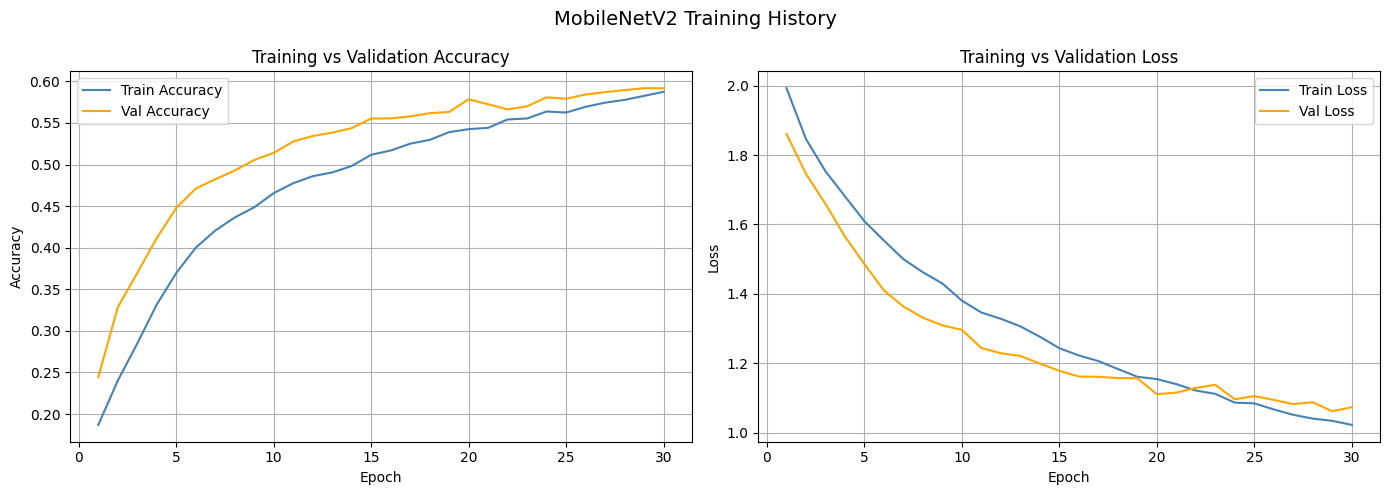

Training curves saved to Drive!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training log from Drive
history_df = pd.read_csv('/content/drive/MyDrive/FER2013_Project/logs/training_log.csv')

print("Training log loaded!")
print(history_df.tail())

epochs_range = range(1, len(history_df) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(epochs_range, history_df['accuracy'], label='Train Accuracy', color='steelblue')
axes[0].plot(epochs_range, history_df['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(epochs_range, history_df['loss'], label='Train Loss', color='steelblue')
axes[1].plot(epochs_range, history_df['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('MobileNetV2 Training History', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FER2013_Project/training_curves.png', dpi=150)
plt.show()
print("Training curves saved to Drive!")

Generating predictions...
225/225 ━━━━━━━━━━━━━━━━━━━━ 3899s 17s/step


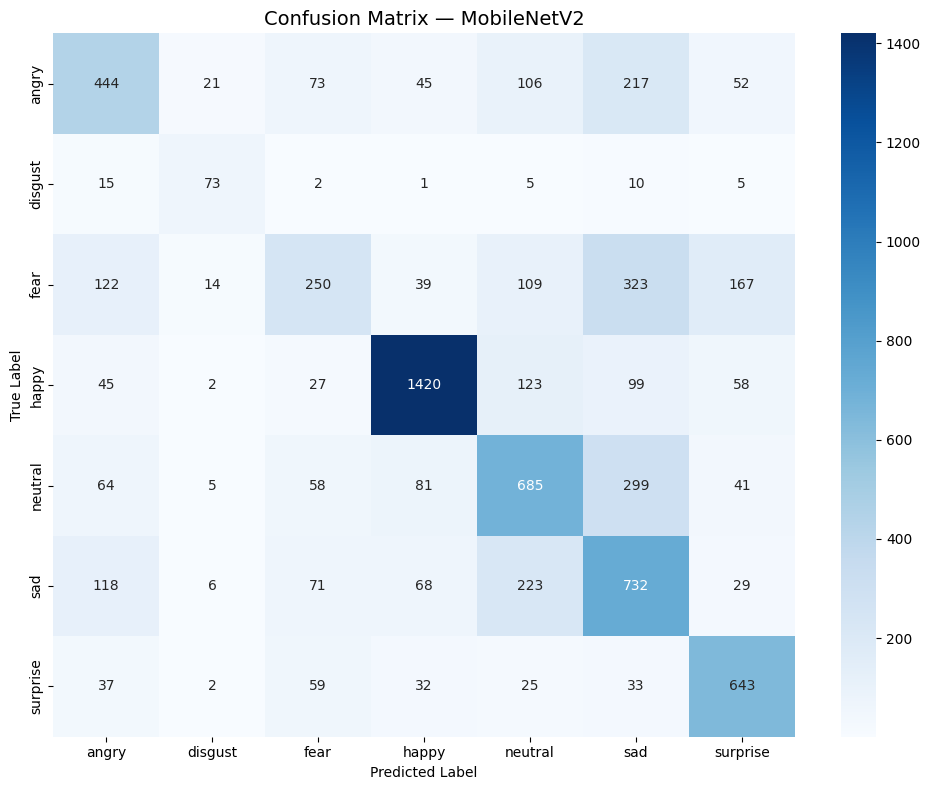


Classification Report:
              precision    recall  f1-score   support

       angry       0.53      0.46      0.49       958
     disgust       0.59      0.66      0.62       111
        fear       0.46      0.24      0.32      1024
       happy       0.84      0.80      0.82      1774
     neutral       0.54      0.56      0.55      1233
         sad       0.43      0.59      0.49      1247
    surprise       0.65      0.77      0.70       831

    accuracy                           0.59      7178
   macro avg       0.58      0.58      0.57      7178
weighted avg       0.59      0.59      0.59      7178



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions on test set
print("Generating predictions...")
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — MobileNetV2', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FER2013_Project/confusion_matrix.png', dpi=150)
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

In [ ]:
import numpy as np

# Save predictions and true labels to Drive
np.save('/content/drive/MyDrive/FER2013_Project/predicted_classes.npy', predicted_classes)
np.save('/content/drive/MyDrive/FER2013_Project/true_classes.npy', true_classes)
print("Predictions saved to Drive!")

Predictions saved to Drive!


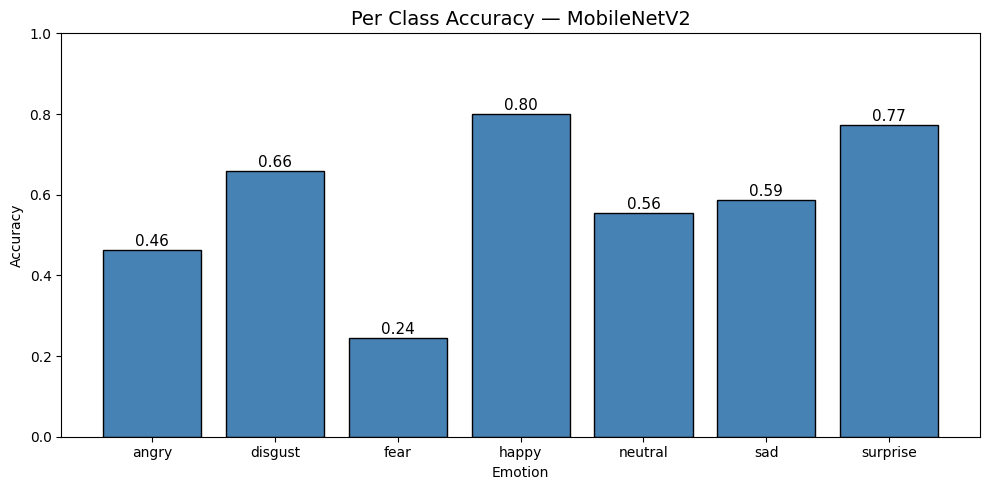

Per class accuracy chart saved to Drive!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate per class accuracy from confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(class_names, per_class_accuracy, color='steelblue', edgecolor='black')
plt.title('Per Class Accuracy — MobileNetV2', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

# Add value labels on top of bars
for bar, acc in zip(bars, per_class_accuracy):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FER2013_Project/per_class_accuracy.png', dpi=150)
plt.show()
print("Per class accuracy chart saved to Drive!")

Using conv layer: Conv_1
Using conv layer: Conv_1
Using conv layer: Conv_1
Using conv layer: Conv_1
Using conv layer: Conv_1
Using conv layer: Conv_1
Using conv layer: Conv_1


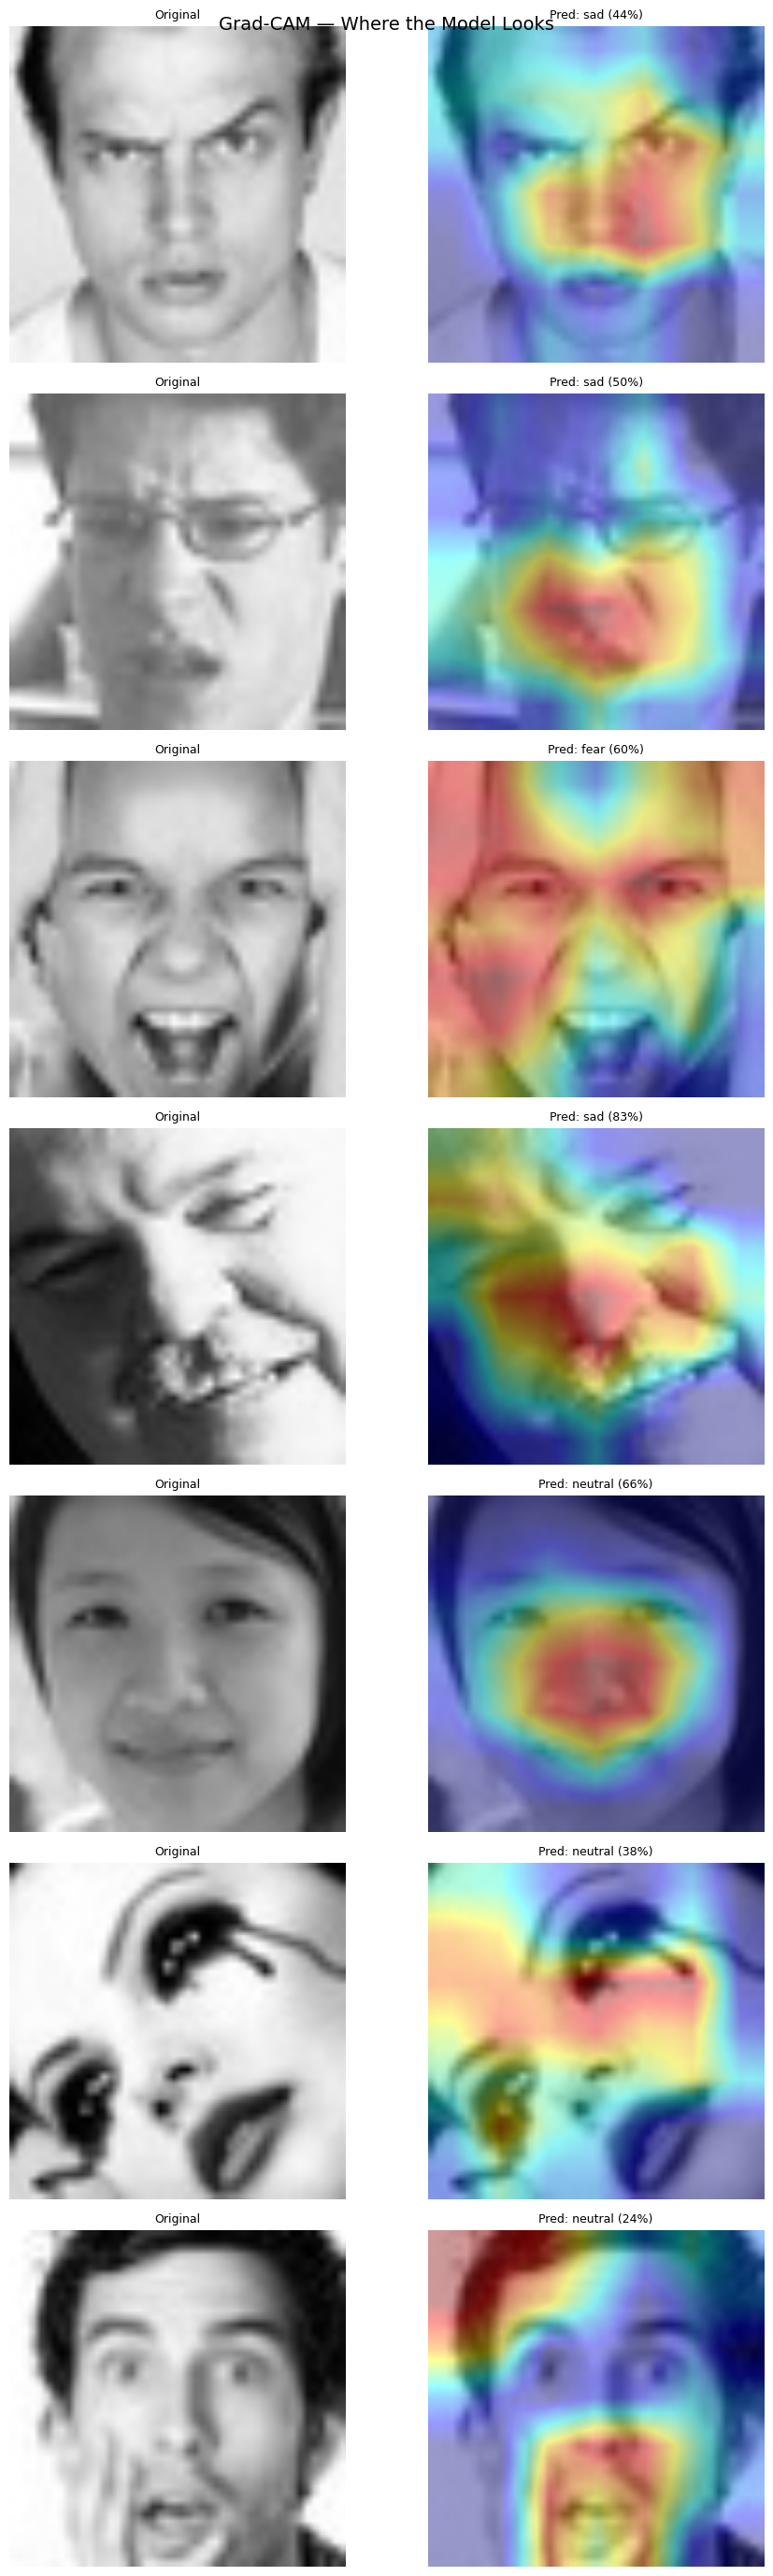

Grad-CAM saved to Drive!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import os

def get_gradcam_heatmap(model, img_array, pred_index=None):
    # Access the MobileNetV2 base model
    base = model.layers[0]

    # Get last conv layer inside MobileNetV2
    last_conv_layer = None
    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer.name
    print("Using conv layer:", last_conv_layer)

    # Build grad model
    grad_model = tf.keras.models.Model(
        inputs=base.input,
        outputs=[base.get_layer(last_conv_layer).output, base.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, base_out = grad_model(img_array)
        # Pass through rest of model
        x = model.layers[1](base_out)  # GlobalAveragePooling
        x = model.layers[2](x)         # Dense 256
        x = model.layers[3](x)         # Dropout
        x = model.layers[4](x)         # Dense 128
        x = model.layers[5](x)         # Dropout
        predictions = model.layers[6](x) # Dense 7

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlaid = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return img, overlaid

# Plot Grad-CAM for one sample per emotion
fig, axes = plt.subplots(7, 2, figsize=(10, 28))

for row, emotion in enumerate(classes):
    folder = os.path.join(TEST_PATH, emotion)
    img_file = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_file)

    # Preprocess
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_array = np.expand_dims(img_resized / 255.0, axis=0).astype(np.float32)

    # Predict
    preds = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_emotion = classes[pred_idx]
    confidence = preds[0][pred_idx]

    # Grad-CAM
    heatmap = get_gradcam_heatmap(model, img_array)
    original, overlaid = overlay_gradcam(img_path, heatmap)

    # Plot
    axes[row, 0].imshow(original)
    axes[row, 0].set_ylabel(f'True: {emotion}', fontsize=10)
    axes[row, 0].set_title('Original', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(overlaid)
    axes[row, 1].set_title(f'Pred: {pred_emotion} ({confidence:.0%})', fontsize=9)
    axes[row, 1].axis('off')

plt.suptitle('Grad-CAM — Where the Model Looks', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FER2013_Project/gradcam.png', dpi=150)
plt.show()
print("Grad-CAM saved to Drive!")

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
import numpy as np

# Rebuild EfficientNetB0 architecture
base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights=None
)

eff_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')
])

# Load trained weights
eff_model.load_weights('/content/drive/MyDrive/FER2013_Project/models/efficientnetb0.weights.h5')

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("EfficientNetB0 loaded successfully!")
print(f"Total params: {eff_model.count_params():,}")

EfficientNetB0 loaded successfully!
Total params: 4,416,426


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

# New test generator with EfficientNet preprocessing
eff_test_datagen = ImageDataGenerator(preprocessing_function=eff_preprocess)

eff_test_generator = eff_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Generate predictions
print("Generating predictions...")
eff_test_generator.reset()
eff_predictions = eff_model.predict(eff_test_generator, verbose=1)
eff_predicted_classes = np.argmax(eff_predictions, axis=1)
eff_true_classes = eff_test_generator.classes

print("\nPredictions done!")

# Save predictions to Drive
np.save('/content/drive/MyDrive/FER2013_Project/eff_predicted_classes.npy', eff_predicted_classes)
np.save('/content/drive/MyDrive/FER2013_Project/eff_true_classes.npy', eff_true_classes)
print("EfficientNetB0 predictions saved to Drive!")

Found 7178 images belonging to 7 classes.
Generating predictions...
225/225 ━━━━━━━━━━━━━━━━━━━━ 3069s 14s/step

Predictions done!
EfficientNetB0 predictions saved to Drive!


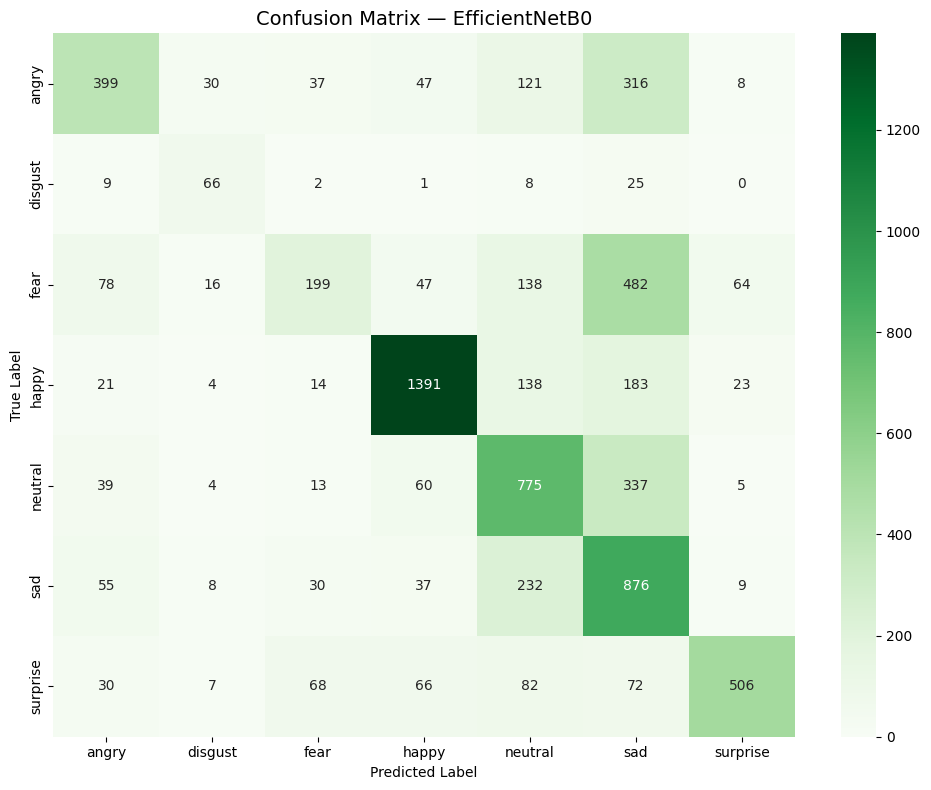


EfficientNetB0 Classification Report:
              precision    recall  f1-score   support

       angry       0.63      0.42      0.50       958
     disgust       0.49      0.59      0.54       111
        fear       0.55      0.19      0.29      1024
       happy       0.84      0.78      0.81      1774
     neutral       0.52      0.63      0.57      1233
         sad       0.38      0.70      0.50      1247
    surprise       0.82      0.61      0.70       831

    accuracy                           0.59      7178
   macro avg       0.61      0.56      0.56      7178
weighted avg       0.63      0.59      0.58      7178



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

class_names = list(eff_test_generator.class_indices.keys())

# Confusion Matrix
cm_eff = confusion_matrix(eff_true_classes, eff_predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — EfficientNetB0', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FER2013_Project/confusion_matrix_eff.png', dpi=150)
plt.show()

# Classification Report
print("\nEfficientNetB0 Classification Report:")
print(classification_report(eff_true_classes, eff_predicted_classes, target_names=class_names))


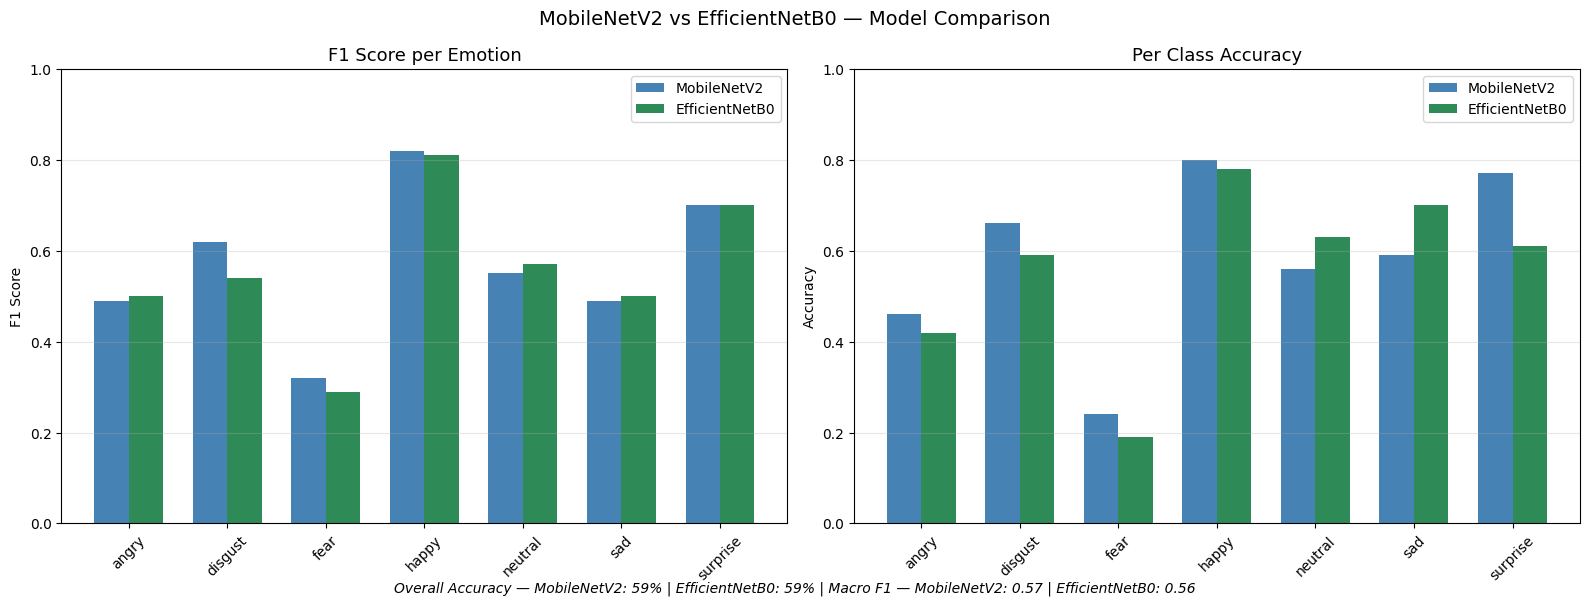

Model comparison chart saved to Drive!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from both classification reports
emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

mobilenet_f1 = [0.49, 0.62, 0.32, 0.82, 0.55, 0.49, 0.70]
efficientnet_f1 = [0.50, 0.54, 0.29, 0.81, 0.57, 0.50, 0.70]

mobilenet_acc = [0.46, 0.66, 0.24, 0.80, 0.56, 0.59, 0.77]
efficientnet_acc = [0.42, 0.59, 0.19, 0.78, 0.63, 0.70, 0.61]

x = np.arange(len(emotions))
width = 0.35

# F1 Score Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].bar(x - width/2, mobilenet_f1, width, label='MobileNetV2', color='steelblue')
bars2 = axes[0].bar(x + width/2, efficientnet_f1, width, label='EfficientNetB0', color='seagreen')
axes[0].set_title('F1 Score per Emotion', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(emotions, rotation=45)
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Per Class Accuracy Comparison
bars3 = axes[1].bar(x - width/2, mobilenet_acc, width, label='MobileNetV2', color='steelblue')
bars4 = axes[1].bar(x + width/2, efficientnet_acc, width, label='EfficientNetB0', color='seagreen')
axes[1].set_title('Per Class Accuracy', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(emotions, rotation=45)
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Overall accuracy annotation
fig.text(0.5, 0.01,
         f'Overall Accuracy — MobileNetV2: 59% | EfficientNetB0: 59% | Macro F1 — MobileNetV2: 0.57 | EfficientNetB0: 0.56',
         ha='center', fontsize=10, style='italic')

plt.suptitle('MobileNetV2 vs EfficientNetB0 — Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FER2013_Project/model_comparison.png', dpi=150)
plt.show()
print("Model comparison chart saved to Drive!")


In [ ]:
import pandas as pd

# Count images in each class for train and test
data = []

for split, path in [('train', TRAIN_PATH), ('test', TEST_PATH)]:
    for emotion in classes:
        folder = os.path.join(path, emotion)
        count = len(os.listdir(folder))
        data.append({'split': split, 'emotion': emotion, 'count': count})

df_counts = pd.DataFrame(data)

# Show train counts
print("=== TRAIN SET ===")
train_df = df_counts[df_counts['split'] == 'train'][['emotion', 'count']]
print(train_df.to_string(index=False))
print(f"\nTotal train images: {train_df['count'].sum()}")

# Show test counts
print("\n=== TEST SET ===")
test_df = df_counts[df_counts['split'] == 'test'][['emotion', 'count']]
print(test_df.to_string(index=False))
print(f"\nTotal test images: {test_df['count'].sum()}")

=== TRAIN SET ===
 emotion  count
   angry   3995
 disgust    436
    fear   4097
   happy   7215
 neutral   4965
     sad   4830
surprise   3171

Total train images: 28709

=== TEST SET ===
 emotion  count
   angry    958
 disgust    111
    fear   1024
   happy   1774
 neutral   1233
     sad   1247
surprise    831

Total test images: 7178


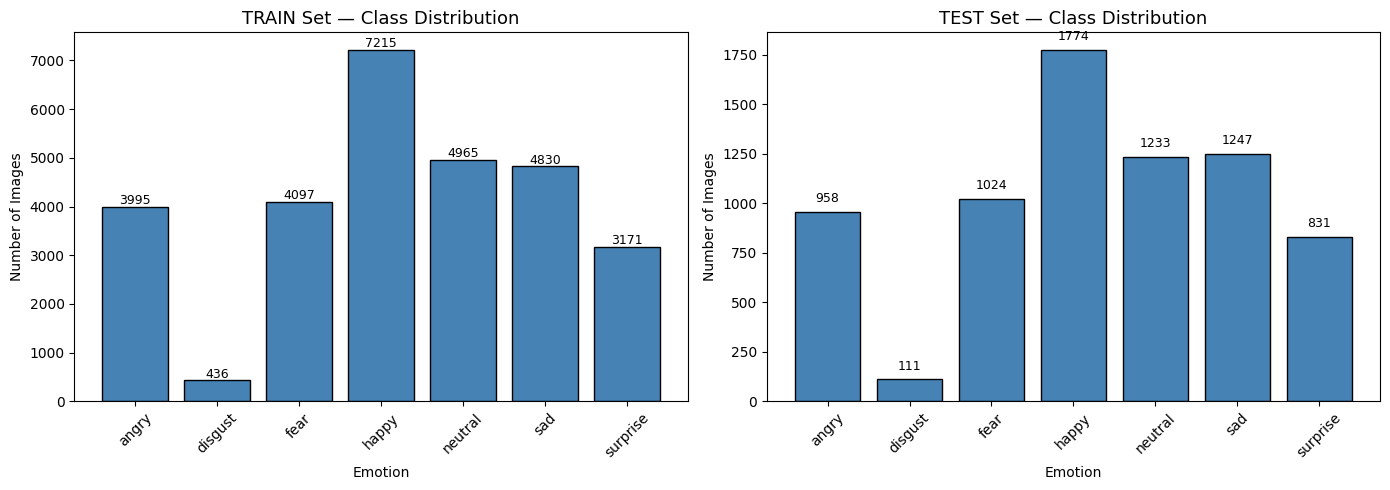

Plot saved to Drive!


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split in zip(axes, ['train', 'test']):
    subset = df_counts[df_counts['split'] == split]
    ax.bar(subset['emotion'], subset['count'], color='steelblue', edgecolor='black')
    ax.set_title(f'{split.upper()} Set — Class Distribution', fontsize=13)
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=45)
    for i, row in subset.iterrows():
        ax.text(row['emotion'], row['count'] + 50, str(row['count']), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FER2013_Project/class_distribution.png', dpi=150)
plt.show()
print("Plot saved to Drive!")

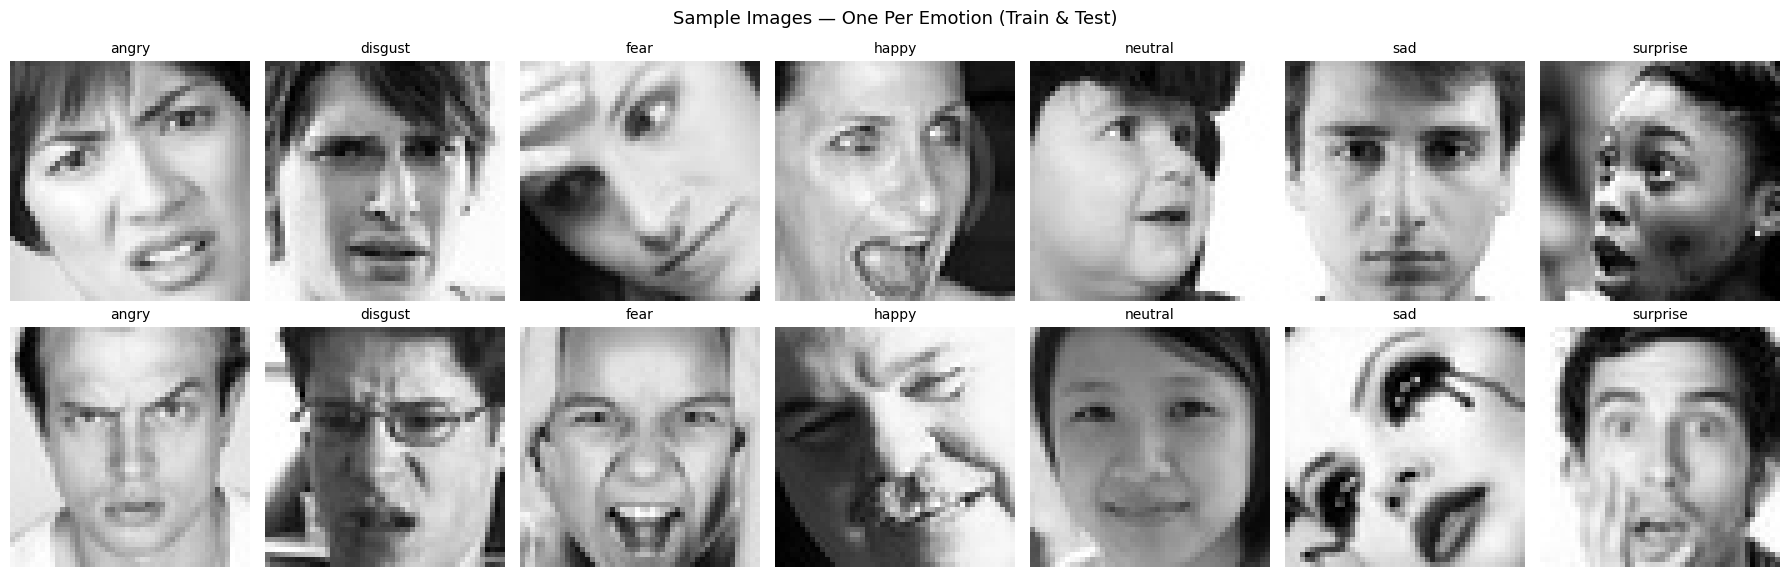

Sample images saved to Drive!


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 7, figsize=(18, 6))

for col, emotion in enumerate(classes):
    for row, split in enumerate(['train', 'test']):
        folder = os.path.join(BASE_PATH, split, emotion)
        img_file = os.listdir(folder)[0]
        img_path = os.path.join(folder, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(emotion, fontsize=10)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(split.upper(), fontsize=10)

plt.suptitle('Sample Images — One Per Emotion (Train & Test)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FER2013_Project/sample_images.png', dpi=150)
plt.show()
print("Sample images saved to Drive!")